In [23]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Set display options
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Dataset Loading

### 1.1 CICIDS2017 Dataset
Download from: https://www.unb.ca/cic/datasets/ids-2017.html

In [24]:
# Define data paths
DATA_DIR = Path('../data/datasets')
CICIDS_DIR = DATA_DIR / 'CICIDS2017'
UNSW_DIR = DATA_DIR / 'UNSW-NB15'

# List available files
print("Looking for datasets...")
print(f"\nCICIDS2017 directory: {CICIDS_DIR}")
print(f"UNSW-NB15 directory: {UNSW_DIR}")

# Check if directories exist
if CICIDS_DIR.exists():
    print(f"\nCICIDS2017 files: {list(CICIDS_DIR.glob('*.csv'))}")
else:
    print("\nCICIDS2017 directory not found. Please download the dataset.")

if UNSW_DIR.exists():
    print(f"\n UNSW-NB15 files: {list(UNSW_DIR.glob('*.csv'))}")
else:
    print("\n UNSW-NB15 directory not found. Please download the dataset.")

Looking for datasets...

CICIDS2017 directory: ..\data\datasets\CICIDS2017
UNSW-NB15 directory: ..\data\datasets\UNSW-NB15

CICIDS2017 directory not found. Please download the dataset.

 UNSW-NB15 directory not found. Please download the dataset.


In [25]:
def load_cicids2017(sample_size=None):
    """
    Load CICIDS2017 dataset.
    
    Args:
        sample_size: Number of rows to sample (None for all)
    Returns:
        DataFrame with combined data
    """
    csv_files = list(CICIDS_DIR.glob('*.csv'))
    
    if not csv_files:
        print("No CSV files found. Creating sample data for demonstration...")
        return create_sample_data()
    
    dfs = []
    for file in csv_files:
        print(f"Loading: {file.name}")
        df = pd.read_csv(file, low_memory=False)
        dfs.append(df)
    
    combined = pd.concat(dfs, ignore_index=True)
    
    if sample_size:
        combined = combined.sample(n=min(sample_size, len(combined)), random_state=42)
    
    return combined


def create_sample_data(n_samples=10000):
    """
    Create sample network traffic data for demonstration.
    """
    np.random.seed(42)
    
    # Attack types
    labels = ['BENIGN'] * int(n_samples * 0.7) + \
             ['DoS Hulk'] * int(n_samples * 0.1) + \
             ['PortScan'] * int(n_samples * 0.08) + \
             ['DDoS'] * int(n_samples * 0.05) + \
             ['Bot'] * int(n_samples * 0.03) + \
             ['FTP-Patator'] * int(n_samples * 0.02) + \
             ['SSH-Patator'] * int(n_samples * 0.02)
    
    n = len(labels)
    
    data = {
        'Flow Duration': np.random.exponential(1000000, n),
        'Total Fwd Packets': np.random.poisson(10, n),
        'Total Backward Packets': np.random.poisson(8, n),
        'Total Length of Fwd Packets': np.random.exponential(500, n),
        'Total Length of Bwd Packets': np.random.exponential(400, n),
        'Flow Bytes/s': np.random.exponential(10000, n),
        'Flow Packets/s': np.random.exponential(100, n),
        'Flow IAT Mean': np.random.exponential(10000, n),
        'Flow IAT Std': np.random.exponential(5000, n),
        'Fwd PSH Flags': np.random.binomial(5, 0.3, n),
        'Bwd PSH Flags': np.random.binomial(3, 0.2, n),
        'Fwd Header Length': np.random.randint(20, 100, n),
        'Bwd Header Length': np.random.randint(20, 80, n),
        'Packet Length Mean': np.random.exponential(100, n),
        'Packet Length Std': np.random.exponential(50, n),
        'Packet Length Variance': np.random.exponential(1000, n),
        'SYN Flag Count': np.random.binomial(3, 0.4, n),
        'ACK Flag Count': np.random.binomial(10, 0.6, n),
        'FIN Flag Count': np.random.binomial(2, 0.3, n),
        'RST Flag Count': np.random.binomial(1, 0.1, n),
        'Destination Port': np.random.choice([80, 443, 22, 21, 8080, 3389], n),
        'Protocol': np.random.choice([6, 17, 1], n, p=[0.7, 0.25, 0.05]),
        'Label': labels
    }
    
    df = pd.DataFrame(data)
    np.random.shuffle(df.values)
    
    print(f"Created sample data with {len(df)} records")
    return df


# Load data
df = load_cicids2017(sample_size=50000)
print(f"\nDataset shape: {df.shape}")

No CSV files found. Creating sample data for demonstration...
Created sample data with 10000 records

Dataset shape: (10000, 23)


## 2. Data Overview

In [26]:
# Basic info
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nShape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
print(f"\nColumn types:")
print(df.dtypes.value_counts())

DATASET OVERVIEW

Shape: (10000, 23)
Memory usage: 1.50 MB

Column types:
float64    10
int32      10
int64       2
str         1
Name: count, dtype: int64


In [27]:
# Display first rows
df.head(10)

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Fwd PSH Flags,Bwd PSH Flags,Fwd Header Length,Bwd Header Length,Packet Length Mean,Packet Length Std,Packet Length Variance,SYN Flag Count,ACK Flag Count,FIN Flag Count,RST Flag Count,Destination Port,Protocol,Label
0,4.692681e+05,9,13,1532.700095,612.218836,11655.968828,110.092942,7456.789659,8833.364447,1,0,41,20,157.650707,42.054761,878.557207,0,2,0,0,443,6,BENIGN
1,3.010121e+06,6,9,215.262931,148.415497,24954.691786,62.744942,2001.056572,6158.345098,3,0,38,50,43.780680,56.696217,193.000931,1,6,1,0,443,17,BENIGN
2,1.316746e+06,10,9,842.330454,241.517351,7855.276337,140.878900,18470.523451,2490.176381,2,0,75,27,131.921755,10.470426,129.419486,3,7,0,0,8080,6,BENIGN
3,9.129426e+05,14,3,797.840790,220.954117,2692.114721,122.991973,13782.839722,3888.570422,3,0,72,43,66.392162,88.719770,38.696999,1,6,0,0,21,6,BENIGN
4,1.696249e+05,16,9,176.045751,227.698377,4135.910453,229.749425,7012.910653,7098.652943,1,0,74,24,55.895141,18.217413,18.988755,0,7,0,0,3389,6,BENIGN
5,1.695963e+05,10,9,142.681256,395.323073,19906.072132,67.991661,4314.566005,994.311820,1,0,78,26,55.166287,54.670123,461.550793,2,3,1,0,80,6,BENIGN
6,5.983877e+04,5,6,383.062005,619.612960,10320.763231,168.013781,8910.445259,1276.217596,3,0,27,49,34.212149,190.082374,701.144129,1,5,1,0,8080,6,BENIGN
7,2.011231e+06,6,8,221.397544,198.718265,3267.238472,96.462755,1235.347787,19363.127681,1,1,89,73,24.133951,23.564566,744.685667,2,9,0,1,21,17,BENIGN
8,9.190822e+05,15,9,1262.157591,395.960434,8613.803351,123.912739,6195.856405,115.155533,1,0,63,32,11.431913,4.636882,47.404197,2,7,1,0,8080,6,BENIGN
9,1.231250e+06,12,3,1218.609629,26.674191,10906.839226,15.962253,990.942624,177.112185,2,3,24,28,322.809413,1.767776,445.266145,1,8,0,0,443,6,BENIGN


In [28]:
# Column names
print("Columns:")
for i, col in enumerate(df.columns):
    print(f"{i+1:3d}. {col}")

Columns:
  1. Flow Duration
  2. Total Fwd Packets
  3. Total Backward Packets
  4. Total Length of Fwd Packets
  5. Total Length of Bwd Packets
  6. Flow Bytes/s
  7. Flow Packets/s
  8. Flow IAT Mean
  9. Flow IAT Std
 10. Fwd PSH Flags
 11. Bwd PSH Flags
 12. Fwd Header Length
 13. Bwd Header Length
 14. Packet Length Mean
 15. Packet Length Std
 16. Packet Length Variance
 17. SYN Flag Count
 18. ACK Flag Count
 19. FIN Flag Count
 20. RST Flag Count
 21. Destination Port
 22. Protocol
 23. Label


In [29]:
# Statistical summary
df.describe()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Fwd PSH Flags,Bwd PSH Flags,Fwd Header Length,Bwd Header Length,Packet Length Mean,Packet Length Std,Packet Length Variance,SYN Flag Count,ACK Flag Count,FIN Flag Count,RST Flag Count,Destination Port,Protocol
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,9.774990e+05,9.973200,7.978100,505.898718,409.588224,10136.446356,100.067497,9977.488960,5022.739326,1.512700,0.592300,59.566400,49.755600,101.735323,50.212891,1005.165320,1.200200,5.974000,0.603000,0.099200,2023.000300,8.569000
std,9.744047e+05,3.127788,2.805353,506.093046,410.787302,10171.059898,99.474028,9989.488766,5058.400668,1.027494,0.692769,23.232726,17.172063,101.880932,50.898781,1014.793267,0.839875,1.558001,0.643143,0.298945,2991.903159,5.052306
min,1.163482e+01,0.000000,0.000000,0.049164,0.014634,0.065720,0.002624,0.047786,0.197929,0.000000,0.000000,20.000000,20.000000,0.000559,0.000115,0.270203,0.000000,1.000000,0.000000,0.000000,21.000000,1.000000
25%,2.827992e+05,8.000000,6.000000,144.163536,117.457129,2906.013644,29.256167,2899.979539,1468.685911,1.000000,0.000000,40.000000,35.000000,29.425073,14.131299,286.828879,1.000000,5.000000,0.000000,0.000000,22.000000,6.000000
50%,6.783150e+05,10.000000,8.000000,348.887458,284.576795,6983.054153,68.832443,7002.436838,3438.611891,1.000000,0.000000,60.000000,50.000000,70.313058,33.957506,698.226474,1.000000,6.000000,1.000000,0.000000,80.000000,6.000000
75%,1.347098e+06,12.000000,10.000000,703.768923,565.992896,13944.929497,138.600260,13651.053358,6931.596950,2.000000,1.000000,80.000000,64.000000,139.298609,68.968987,1380.701098,2.000000,7.000000,1.000000,0.000000,3389.000000,17.000000
max,8.172446e+06,24.000000,23.000000,4636.581606,4581.290437,88190.646035,907.229484,109813.995298,46574.794734,5.000000,3.000000,99.000000,79.000000,923.672649,478.186139,9391.415887,3.000000,10.000000,2.000000,1.000000,8080.000000,17.000000


## 3. Target Variable Analysis

In [30]:
# Find label column
label_col = None
for col in ['Label', 'label', 'attack_cat', 'Attack']:
    if col in df.columns:
        label_col = col
        break

if label_col:
    print(f"Label column: {label_col}")
    print(f"\nClass distribution:")
    class_dist = df[label_col].value_counts()
    print(class_dist)
    
    print(f"\nClass percentages:")
    print((class_dist / len(df) * 100).round(2))
else:
    print("No label column found!")

Label column: Label

Class distribution:
Label
BENIGN         7000
DoS Hulk       1000
PortScan        800
DDoS            500
Bot             300
FTP-Patator     200
SSH-Patator     200
Name: count, dtype: int64

Class percentages:
Label
BENIGN         70.0
DoS Hulk       10.0
PortScan        8.0
DDoS            5.0
Bot             3.0
FTP-Patator     2.0
SSH-Patator     2.0
Name: count, dtype: float64


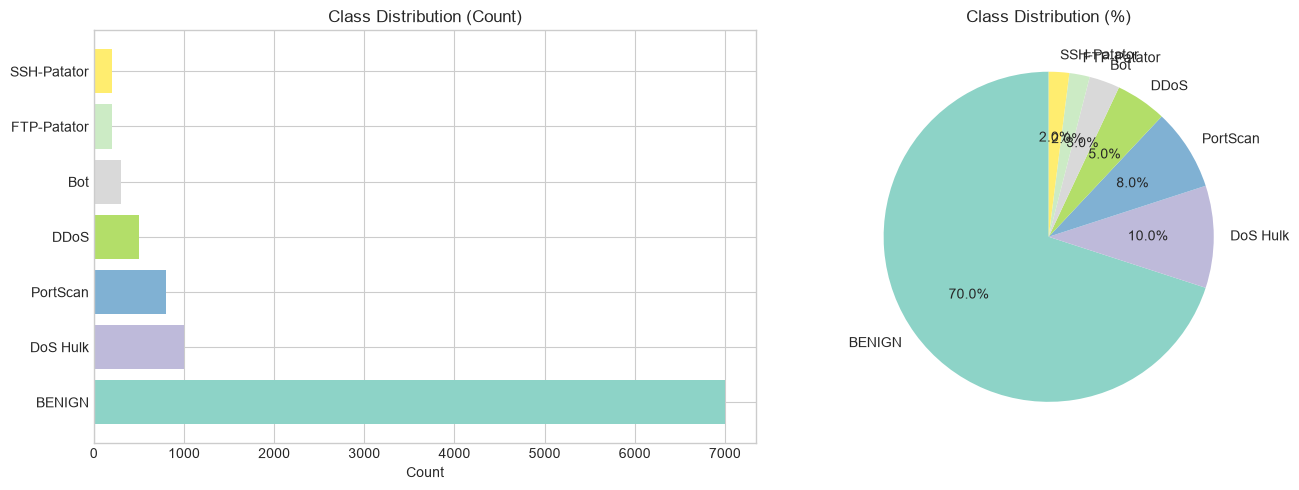


 Note: Dataset is highly imbalanced - BENIGN class dominates


In [31]:
# Visualize class distribution
if label_col:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart
    class_dist = df[label_col].value_counts()
    colors = plt.cm.Set3(np.linspace(0, 1, len(class_dist)))
    
    axes[0].barh(range(len(class_dist)), class_dist.values, color=colors)
    axes[0].set_yticks(range(len(class_dist)))
    axes[0].set_yticklabels(class_dist.index)
    axes[0].set_xlabel('Count')
    axes[0].set_title('Class Distribution (Count)')
    
    # Pie chart
    axes[1].pie(class_dist.values, labels=class_dist.index, autopct='%1.1f%%',
                colors=colors, startangle=90)
    axes[1].set_title('Class Distribution (%)')
    
    plt.tight_layout()
    plt.show()
    
    print("\n Note: Dataset is highly imbalanced - BENIGN class dominates")

## 4. Feature Analysis

In [32]:
# Identify numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numeric features: {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

Numeric features: 22
Categorical features: 1


In [33]:
# Missing values analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)

print("Missing Values:")
print(missing_df[missing_df['Missing Count'] > 0])

if missing_df['Missing Count'].sum() == 0:
    print(" No missing values found!")

Missing Values:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []
 No missing values found!


In [34]:
# Check for infinite values
inf_counts = {}
for col in numeric_cols:
    inf_count = np.isinf(df[col]).sum()
    if inf_count > 0:
        inf_counts[col] = inf_count

if inf_counts:
    print("Columns with infinite values:")
    for col, count in inf_counts.items():
        print(f"  {col}: {count}")
else:
    print(" No infinite values found!")

 No infinite values found!


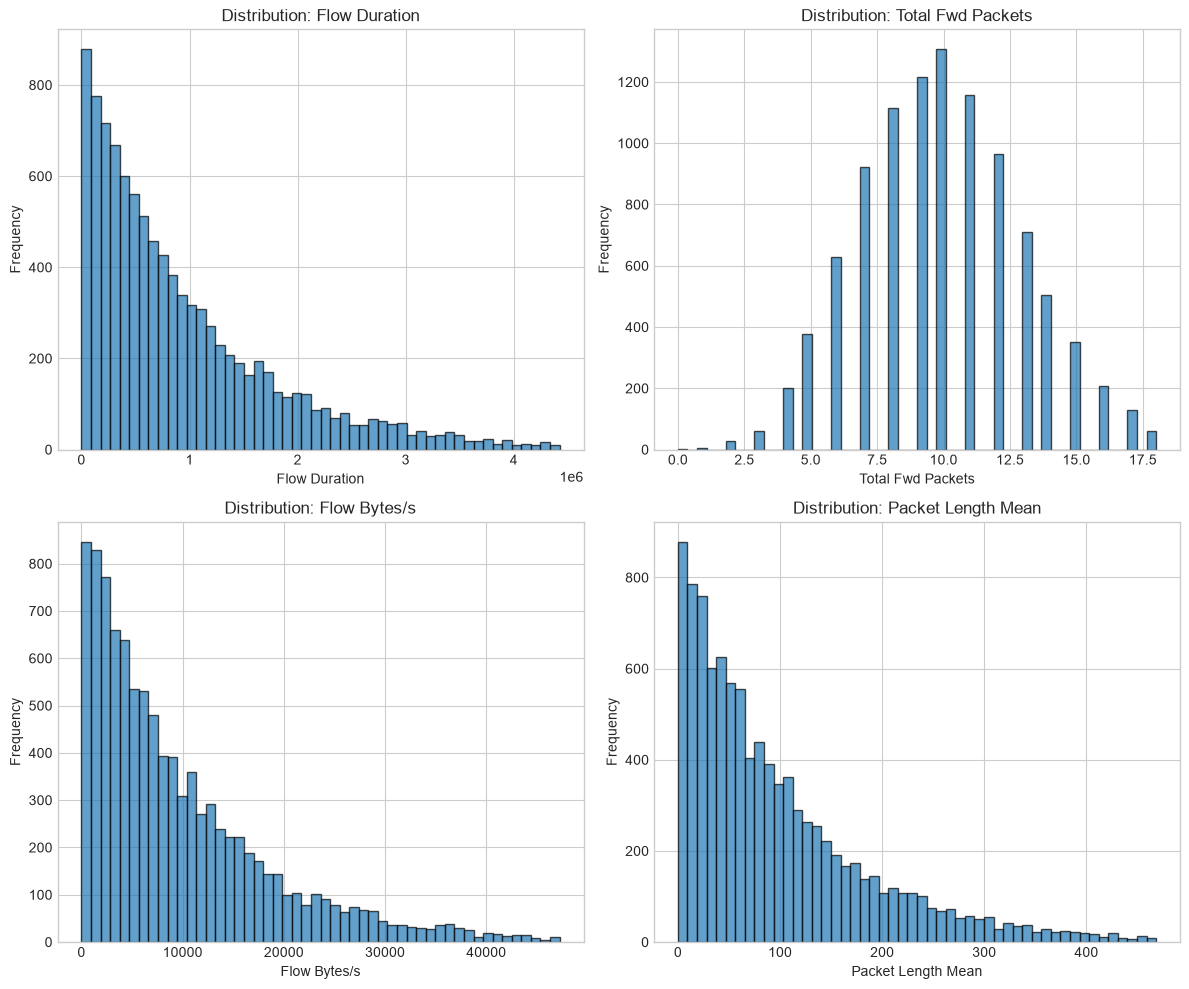

In [35]:
# Feature distributions
sample_features = ['Flow Duration', 'Total Fwd Packets', 'Flow Bytes/s', 'Packet Length Mean']
sample_features = [f for f in sample_features if f in df.columns][:4]

if sample_features:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for idx, feature in enumerate(sample_features):
        # Remove infinites and outliers for visualization
        data = df[feature].replace([np.inf, -np.inf], np.nan).dropna()
        q99 = data.quantile(0.99)
        data = data[data <= q99]
        
        axes[idx].hist(data, bins=50, edgecolor='black', alpha=0.7)
        axes[idx].set_xlabel(feature)
        axes[idx].set_ylabel('Frequency')
        axes[idx].set_title(f'Distribution: {feature}')
    
    plt.tight_layout()
    plt.show()

## 5. Correlation Analysis

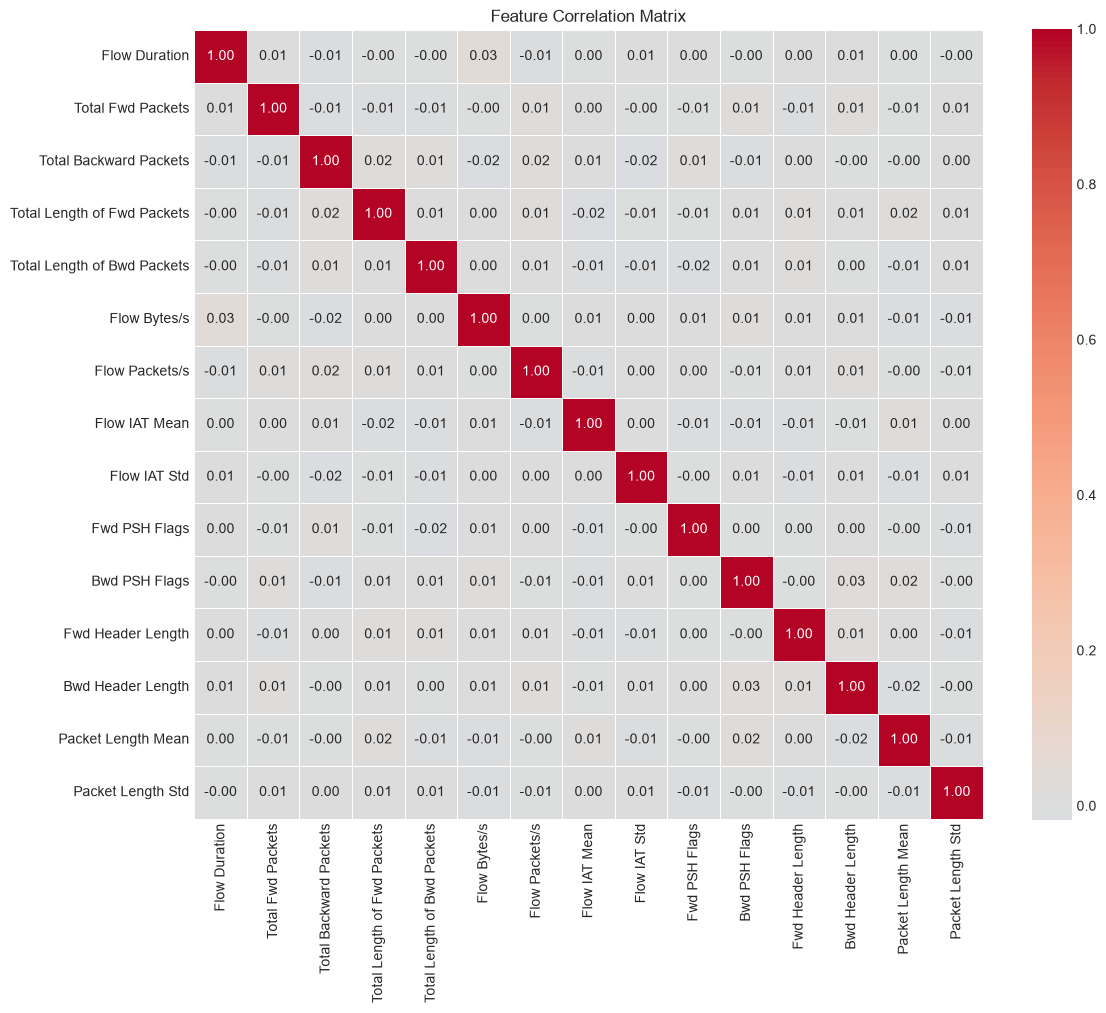

In [36]:
# Select top features for correlation
top_features = numeric_cols[:15] if len(numeric_cols) > 15 else numeric_cols

# Clean data for correlation
corr_df = df[top_features].replace([np.inf, -np.inf], np.nan).dropna()
correlation_matrix = corr_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [38]:
# Find highly correlated features
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = abs(correlation_matrix.iloc[i, j])
        if corr_val > 0.9:
            high_corr_pairs.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })

if high_corr_pairs:
    print("Highly correlated feature pairs (|r| > 0.9):")
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
    print(high_corr_df.to_string(index=False))
else:
    print("No highly correlated pairs found (|r| > 0.9)")

No highly correlated pairs found (|r| > 0.9)


## 6. Attack-Specific Analysis

In [39]:
if label_col:
    # Compare feature means across attack types
    feature_cols = [c for c in numeric_cols if c != label_col][:10]
    
    attack_stats = df.groupby(label_col)[feature_cols].mean()
    
    print("Mean feature values by attack type:")
    display(attack_stats.round(2))

Mean feature values by attack type:


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Fwd PSH Flags
Label,,,,,,,,,,
BENIGN,990864.91,10.02,8.00,506.65,407.97,10149.67,99.92,9948.77,5046.66,1.51
Bot,939389.01,9.84,7.81,520.50,408.44,9444.91,100.49,9929.35,5322.28,1.52
DDoS,979774.85,9.81,7.98,534.44,403.36,11000.24,102.96,10371.07,4709.43,1.53
DoS Hulk,931423.83,9.80,8.00,504.73,418.98,9844.55,99.17,10268.40,4920.26,1.49
FTP-Patator,926385.90,9.99,7.63,496.97,379.73,11251.72,99.47,9447.93,4853.24,1.54
PortScan,934231.39,9.98,7.94,481.47,422.24,10126.27,101.77,9805.52,5035.30,1.52
SSH-Patator,1015724.48,9.68,8.04,498.68,415.85,8936.25,95.58,9833.69,5151.07,1.48


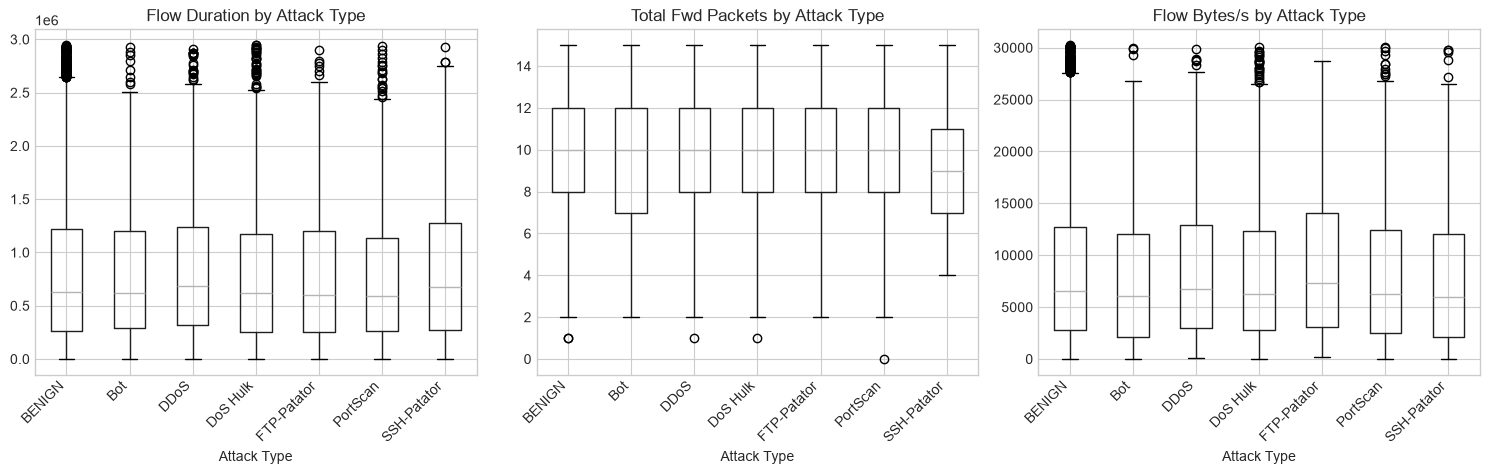

In [40]:
if label_col:
    # Box plots for key features by attack type
    key_features = ['Flow Duration', 'Total Fwd Packets', 'Flow Bytes/s']
    key_features = [f for f in key_features if f in df.columns][:3]
    
    if key_features:
        fig, axes = plt.subplots(1, len(key_features), figsize=(15, 5))
        if len(key_features) == 1:
            axes = [axes]
        
        for idx, feature in enumerate(key_features):
            # Clean and cap outliers
            plot_df = df[[label_col, feature]].copy()
            plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna()
            q95 = plot_df[feature].quantile(0.95)
            plot_df = plot_df[plot_df[feature] <= q95]
            
            plot_df.boxplot(column=feature, by=label_col, ax=axes[idx])
            axes[idx].set_title(f'{feature} by Attack Type')
            axes[idx].set_xlabel('Attack Type')
            plt.sca(axes[idx])
            plt.xticks(rotation=45, ha='right')
        
        plt.suptitle('')
        plt.tight_layout()
        plt.show()

## 7. Port Analysis

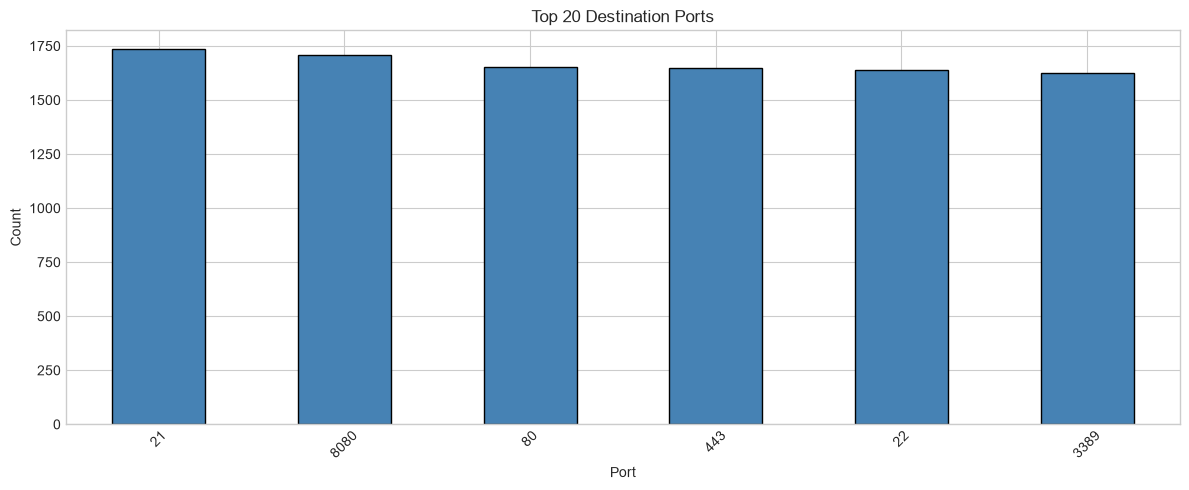


Port distribution by attack type:
Destination Port  21    22    80    443   3389  8080
Label                                               
BENIGN            1205  1147  1162  1160  1116  1210
Bot                 51    36    55    54    46    58
DDoS                98    87    92    72    75    76
DoS Hulk           166   175   155   163   178   163
FTP-Patator         37    26    37    28    30    42
PortScan           141   126   121   134   149   129
SSH-Patator         37    40    29    35    30    29


In [41]:
# Analyze destination ports
port_col = None
for col in ['Destination Port', 'dst_port', 'Dst Port']:
    if col in df.columns:
        port_col = col
        break

if port_col:
    # Top ports
    top_ports = df[port_col].value_counts().head(20)
    
    plt.figure(figsize=(12, 5))
    top_ports.plot(kind='bar', color='steelblue', edgecolor='black')
    plt.xlabel('Port')
    plt.ylabel('Count')
    plt.title('Top 20 Destination Ports')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Port distribution by attack type
    if label_col:
        print("\nPort distribution by attack type:")
        port_attack = df.groupby([label_col, port_col]).size().unstack(fill_value=0)
        print(port_attack.iloc[:, :10])

## 8. Protocol Analysis

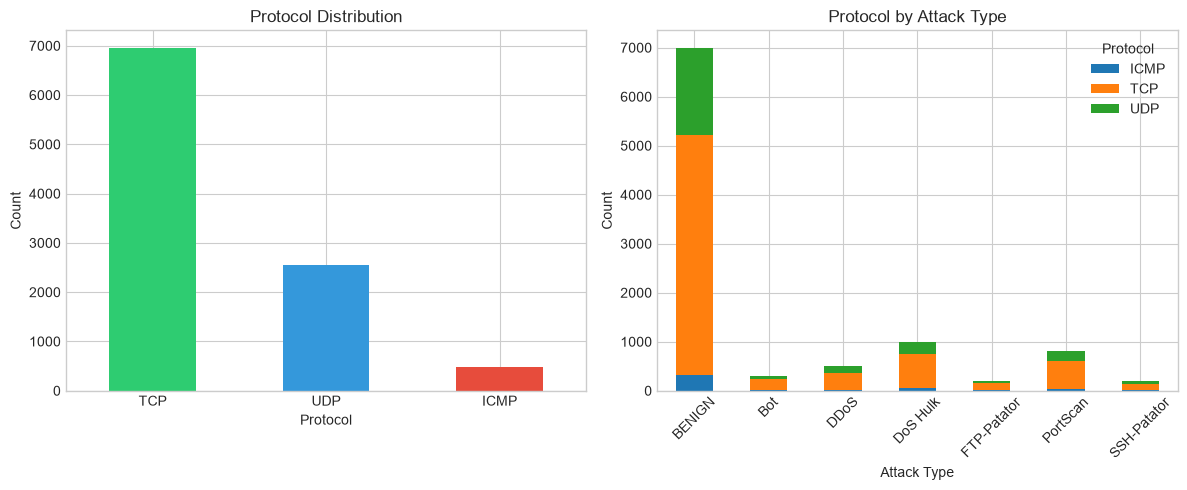

In [42]:
# Analyze protocols
proto_col = None
for col in ['Protocol', 'protocol', 'Proto']:
    if col in df.columns:
        proto_col = col
        break

if proto_col:
    # Map protocol numbers
    proto_map = {6: 'TCP', 17: 'UDP', 1: 'ICMP'}
    df['Protocol_Name'] = df[proto_col].map(proto_map).fillna('Other')
    
    proto_dist = df['Protocol_Name'].value_counts()
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Bar chart
    proto_dist.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#3498db', '#e74c3c', '#95a5a6'])
    axes[0].set_xlabel('Protocol')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Protocol Distribution')
    axes[0].tick_params(axis='x', rotation=0)
    
    # Protocol by attack
    if label_col:
        proto_attack = df.groupby([label_col, 'Protocol_Name']).size().unstack(fill_value=0)
        proto_attack.plot(kind='bar', stacked=True, ax=axes[1])
        axes[1].set_xlabel('Attack Type')
        axes[1].set_ylabel('Count')
        axes[1].set_title('Protocol by Attack Type')
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].legend(title='Protocol')
    
    plt.tight_layout()
    plt.show()

## 9. Data Quality Summary

In [43]:
# Summary report
print("=" * 60)
print("DATA QUALITY SUMMARY")
print("=" * 60)

print(f"\n Dataset Size: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f" Memory Usage: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")

print(f"\n Numeric Features: {len(numeric_cols)}")
print(f" Categorical Features: {len(categorical_cols)}")

missing_total = df.isnull().sum().sum()
print(f"\n{'' if missing_total == 0 else ''} Missing Values: {missing_total}")

inf_total = sum(np.isinf(df[col]).sum() for col in numeric_cols if df[col].dtype in ['float64', 'float32'])
print(f"{'' if inf_total == 0 else ''} Infinite Values: {inf_total}")

if label_col:
    n_classes = df[label_col].nunique()
    print(f"\n Target Classes: {n_classes}")
    
    # Class imbalance ratio
    class_dist = df[label_col].value_counts()
    imbalance_ratio = class_dist.max() / class_dist.min()
    print(f" Class Imbalance Ratio: {imbalance_ratio:.2f}x")

print("\n" + "=" * 60)
print("RECOMMENDATIONS")
print("=" * 60)
print("\n1. Handle class imbalance (SMOTE, class weights, undersampling)")
print("2. Remove highly correlated features (>0.95)")
print("3. Scale features before ML training")
print("4. Consider log transformation for skewed features")
print("5. Replace infinite values with NaN and impute")

DATA QUALITY SUMMARY

 Dataset Size: 10,000 rows × 24 columns
 Memory Usage: 1.62 MB

 Numeric Features: 22
 Categorical Features: 1

 Missing Values: 0
 Infinite Values: 0

 Target Classes: 7
 Class Imbalance Ratio: 35.00x

RECOMMENDATIONS

1. Handle class imbalance (SMOTE, class weights, undersampling)
2. Remove highly correlated features (>0.95)
3. Scale features before ML training
4. Consider log transformation for skewed features
5. Replace infinite values with NaN and impute


In [44]:
# Save exploration results
exploration_summary = {
    'n_samples': len(df),
    'n_features': len(df.columns),
    'numeric_features': len(numeric_cols),
    'categorical_features': len(categorical_cols),
    'missing_values': int(missing_total),
    'infinite_values': int(inf_total),
    'n_classes': int(df[label_col].nunique()) if label_col else 0,
    'class_distribution': df[label_col].value_counts().to_dict() if label_col else {}
}

print(" Exploration summary saved to data/processed/exploration_summary.json")

 Exploration summary saved to data/processed/exploration_summary.json


## 10. Next Steps

Proceed to the next notebooks:
1. **02_feature_engineering.ipynb** - Feature selection and transformation
2. **03_model_training.ipynb** - Train ML models
3. **04_model_evaluation.ipynb** - Evaluate model performance
4. **05_explainability.ipynb** - SHAP analysis